<a href="https://colab.research.google.com/github/KasiR07/AES-Image-Encryption/blob/main/Placement_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import numpy as np

Load and Read the Dataset

In [2]:
df=pd.read_csv('/content/placement.csv')

Data preprocessing

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.tail()

,Unnamed: 0,cgpa,iq,placement
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1
99,99,6.2,113.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df.shape

(100, 4)

In [9]:
df.size

400

iloc stands for integer location ie. select colums from that location

In [10]:
df = df.iloc[:,1:] #Here we need to select all the rows but the columns start from 1st and not 0th

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


EDA

In [13]:
import matplotlib.pyplot as plt

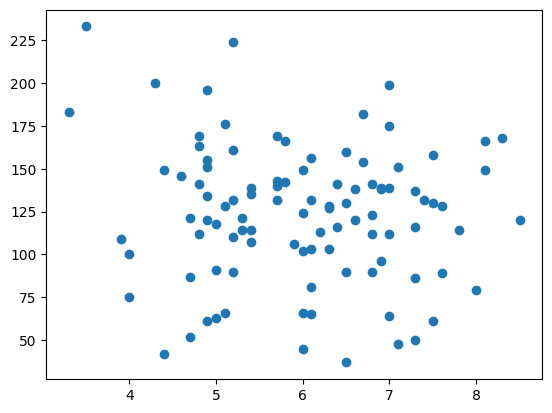

In [14]:
plt.scatter(df['cgpa'],df['iq'])

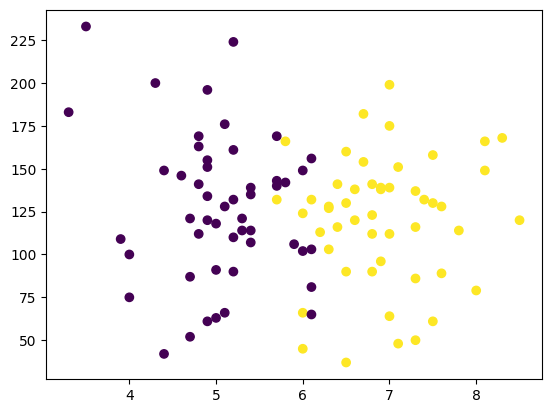

In [19]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

Extract I/p and O/p Values

In [40]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [35]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [41]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


Train Test Split Function (Cross Validation)

In [47]:
from sklearn.model_selection import train_test_split


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1)

In [51]:
X_train

,cgpa,iq
2,5.3,121.0
86,5.1,128.0
10,6.0,45.0
75,4.8,169.0
44,7.5,61.0
...,...,...
58,8.0,79.0
54,6.4,141.0
37,8.1,149.0
12,5.4,139.0


In [52]:
y_train

,placement
2,0
86,0
10,1
75,0
44,1
...,...
58,1
54,1
37,1
12,0


In [53]:
X_test

,cgpa,iq
15,5.1,176.0
95,4.3,200.0
67,5.0,118.0
48,6.6,138.0
57,6.5,130.0
1,5.9,106.0
32,7.0,139.0
97,6.7,182.0
0,6.8,123.0
26,7.0,199.0


In [54]:
y_test

,placement
15,0
95,0
67,0
48,1
57,1
1,0
32,1
97,1
0,1
26,1


Scaling the Model(always best to do)

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()

fit and transform to understand the data and the transform it

In [57]:
X_train = scaler.fit_transform(X_train)

In [58]:
X_train

array([[-0.58644907,  0.01217489],
       [-0.75893409,  0.19055111],
       [ 0.0172485 , -1.92448126],
       [-1.01766163,  1.23532613],
       [ 1.31088616, -1.51676418],
       [ 0.87967361,  1.38822004],
       [ 0.27597603,  0.19055111],
       [-0.67269158, -0.26813061],
       [ 0.0172485 , -1.38935259],
       [ 0.70718859, -0.77777696],
       [ 0.53470357, -0.01330743],
       [ 0.44846106, -0.77777696],
       [-1.10390414,  0.01217489],
       [ 0.96591612, -1.84803431],
       [ 0.0172485 ,  0.72567978],
       [-1.36263167, -2.00092821],
       [-0.15523652,  1.15887918],
       [-1.70760171, -1.16001173],
       [ 0.10349101, -0.44650683],
       [ 0.0172485 , -0.47198915],
       [-0.93141912, -0.01330743],
       [-1.36263167,  0.72567978],
       [ 0.27597603, -0.44650683],
       [-0.67269158, -0.77777696],
       [ 2.00082625,  1.20984382],
       [-1.79384422, -0.29361293],
       [ 0.10349101, -1.00711782],
       [ 0.10349101,  0.29248038],
       [-0.8451766 ,

In [59]:
X_test = scaler.transform(X_test)

In [60]:
X_test

array([[-0.75893409,  1.41370236],
       [-1.44887418,  2.02527798],
       [-0.8451766 , -0.06427207],
       [ 0.53470357,  0.44537429],
       [ 0.44846106,  0.24151574],
       [-0.06899401, -0.37005988],
       [ 0.87967361,  0.4708566 ],
       [ 0.62094608,  1.56659626],
       [ 0.70718859,  0.06313952],
       [ 0.87967361,  1.99979567]])

Model Selection

In [61]:
from sklearn.linear_model import LogisticRegression

In [63]:
clf = LogisticRegression() #Clf is an object to access the Logistic Regression Functions

Model Training

In [64]:
clf.fit(X_train, y_train)

LogisticRegression()

In [66]:
y_pred = clf.predict(X_test)

In [68]:
y_pred

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1])

In [69]:
y_test

,placement
15,0
95,0
67,0
48,1
57,1
1,0
32,1
97,1
0,1
26,1


Calculate Accuracy

In [70]:
from sklearn.metrics import accuracy_score

In [71]:
accuracy_score(y_test, y_pred)

1.0

Visualization

In [76]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

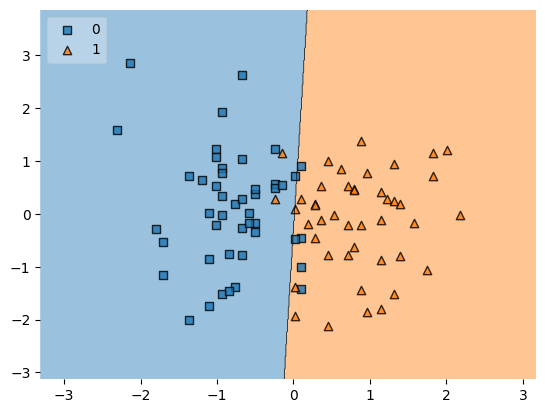

In [79]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [80]:
import pickle #pickle converts any object into a file